In [1]:
import os
import re
import math
import shutil
import subprocess

from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.dates import DateFormatter
from dateutil.tz import tzutc, tzlocal
from scipy import stats
from scipy.optimize import brentq, curve_fit, fsolve


import sys
import signal
import tempfile
import time
from collections import Counter
from IPython.display import clear_output

In [2]:
%load_ext autoreload
%autoreload 2

import GSSHA_set_and_run_functions as gf

%load_ext autoreload
%autoreload 2

import GSSHA_post_process_functions as gppf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Paths and iteration files for running all the model simulations

paths that don't change

In [3]:
cwd = os.getcwd()
script_dir = Path.cwd() 
GSSHA_executables = script_dir / 'GSSHA_executables'

GSSHA Model Name and iteration file input

In [4]:
GSSHA_prj_name = "Waialua_FIM_testing"
model_dir = script_dir / GSSHA_prj_name

xys_tsf_iteration_file_name = GSSHA_prj_name + "_ITERATION"
xys_tsf_iteration_value = "155.0"

# Force shutdown of any GSSHA model running in model folder

In [5]:
 # Use  if you're in Jupyter or interactive session
process = gf.GSSHA_auto_shutdown(model_dir)
gf.force_shutdown_gssha(process=process, model_dir=model_dir)

No gssha.exe found. The model folder may already be clean.
GSSHA stopped and gssha.exe is unlocked.


True

# 1.0 Run flow testing for model development

Set up test flows and total modeling time (see example of Waialua below)

In [6]:
FLOW_TEST = [2]
tot_time = 1000
test_input_flow_results_dir = model_dir / "TEST_INPUT_FLOW_SIMULATIONS"

Run test flows in model with total time unchanged for each flow (be reasonable on high test flows, it is not necessary to reach the max flood stage yet due to computation requirements of those runs.

A window will pop up where you can type q to exit the simulation. ONLY type q if the model looks like it has converged. A dataframe will pop upshowing the changes in the flood through each timestep. If the model run time is excessively long, evaluate the dataframe and decide if the model has converged.   

In [7]:
gf.cleanup_model_dir(model_dir)

for flow in FLOW_TEST:
    new_value = float(flow)
    cfs_flow_for_filenames = round(flow*35.31467)
    
    output_file = (
        test_input_flow_results_dir
        / f"{GSSHA_prj_name}_OUTPUT-input-flow-cfs-{cfs_flow_for_filenames}.tsf"
    )
    
    if output_file.exists():
        print(f"{output_file.name} already exists. Skipping...")
        continue

    
    df_prj = gf.read_prj_file(GSSHA_prj_name +".prj", prj_folder_path = model_dir)
    

    #ITERATION FILES
    gf.replace_value_in_gssha_file(read_dir=model_dir , gssha_sample_file = xys_tsf_iteration_file_name + ".tsf", save_filename = GSSHA_prj_name + "_bc.tsf", old_value =xys_tsf_iteration_value, new_value = new_value)
    gf.replace_value_in_gssha_file(read_dir= model_dir, gssha_sample_file = xys_tsf_iteration_file_name + ".xys", save_filename = GSSHA_prj_name + ".xys", old_value = xys_tsf_iteration_value, new_value = new_value)
    ##UPDATE THE ITERATION W THE NEW XYS AND TSF FILE

    #!!!!write a function to copy with specified cfs flows in name!!!

    #SAVE TEXT XYS file for knowing the input flows for model run
    #These files are for the 

    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + "_bc.tsf",
        output_folder=test_input_flow_results_dir,
        new_filename=GSSHA_prj_name + "_OUTPUT-input-flow-cfs-" + str(cfs_flow_for_filenames) + ".tsf"
    )


    

    df_prj.loc['TOT_TIME', 'Value'] = tot_time
    
    df_prj = df_prj.reset_index()


    #UPDATE PRJ FILE WHICH CONTAINS THE PATHS
    gf.convert_df_to_prj(
        df_prj,
        output_folder= model_dir,
        prj_file_name=GSSHA_prj_name
    )


    gf.copy_gssha_apps_to_model(GSSHA_executables, model_dir)
    
    #this function allows you to see when model convergence occurs so you can quit the run
    return_code = gf.run_gssha_convergence_view(
    MODEL_DIR=model_dir,
    PROJECT_FILE=GSSHA_prj_name + ".prj",
    DEP_FILE=GSSHA_prj_name + ".dep",
    cell_size=10,
    dep_check_seconds=15,
    display_last_n=10
)
    # move_and_rename_gssha_output(MODEL_DIR, RESULTS_DIR, output_description = "TEST_RUN" + first_date, extension = "otl")
    gf.cleanup_model_dir(model_dir)

    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + ".dep",
        output_folder=test_input_flow_results_dir,
        new_filename=GSSHA_prj_name + "_OUTPUT-timeseries-depth-m-" + str(cfs_flow_for_filenames) + ".dep"
    )

    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + ".gfl",
        output_folder=test_input_flow_results_dir,
        new_filename=GSSHA_prj_name + "_OUTPUT-maxflood-dep-m-" + str(cfs_flow_for_filenames) + ".gfl"
    )
    
    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + ".oqc",
        output_folder=test_input_flow_results_dir,
        new_filename=GSSHA_prj_name + "_OUTPUT_USGS-STATS-location-cms-" + str(cfs_flow_for_filenames) + ".oqc"
    )
    
    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + ".ows",
        output_folder=test_input_flow_results_dir,
        new_filename=GSSHA_prj_name + "_OUTPUT_WSE-active-USGS-gauge-m-" + str(cfs_flow_for_filenames) + ".ows"
    )


✔️ Cleaned up model folder.
Waialua_FIM_testing_OUTPUT-input-flow-cfs-71.tsf already exists. Skipping...


# 2.0 Read TEST FLOW results, calibrate for initial flood stage model inputs

Set up gauge datum offset and min/max flood stages

In [8]:
Gauge_Datum_offset = 13.835
#offset between LMSL and gauge recordings

#create directory to store model output and the input parameters
calibration_one_results_dir = model_dir / ("CALIBRATION_STAGE_MAPS_WITH_OFFSET_" + str(Gauge_Datum_offset))
calibration_one_results_dir.mkdir(parents=True, exist_ok=True)

Min_flood_stage = 26 
#minor flood stage from NWS (of 1-2 feet lower if you prefer)

Max_flood_stage = 34
#max recorded gauge level or NWS major reported stage (or 1-3 feet over if you have ample computer time, a couple feet higher is better for calibration)

Create a dataframe to store results. we will use power law curves to derive connections between the input flows and gauge levels in the model. Then we will evaluate convergence thresholds to ensure run time is not excessively long. 

In [9]:
#SET UP CALIBRATION FROM INITIAL INPUT FLOWS

# Once Offset is determined, set up model paramters for running stage height maps
gage_readings = np.arange(
    Min_flood_stage,
    Max_flood_stage + 1, 
    1,
).tolist()

#Set up the storage of results
modeling_test_results= {"gauge_readings_ft":[],
                            "expected_WSE_m":[],
                            "expected_WSE_ft":[],  
                            "convergence_time": [], 
                            "input_flows":[]}

#Fill in some metadata about gauge readings, expected model outputs to figure out the rest
expected_model_outputs = [x - Gauge_Datum_offset for x in gage_readings]
modeling_test_results["gauge_readings_ft"] = gage_readings
modeling_test_results["expected_WSE_ft"] = expected_model_outputs
modeling_test_results["expected_WSE_m"]  = [round(ft * 0.3048, 2) for ft in expected_model_outputs]

MODEL INPUT FLOW FOR EXPECTED WSE

In [ ]:
modeling_test_results["input_flows"] = gppf.get_input_flows_for_gauge_stages(
    modeling_results_directory = test_input_flow_results_dir,
    requested_WSE =  modeling_test_results["expected_WSE_m"],
    plot=True,
)

MODEL TIMESTEP CONVERGENCE (YOU CHANGE PARAMETERS BASED ON GRAPH)

In [ ]:
gppf.view_timestep_convergence(model_results_directory = test_input_flow_results_dir, area_change_threshold = 1000, number_timesteps_below_threshold = 6)

In [ ]:
medium_flow_threshold = 400
high_flow_threshold = 1000

low_flow_timing = 1000
medium_flow_timing = 420
high_flow_timing = 330


modeling_test_results["convergence_time"] = gppf.predict_timestep_convergence(
    modeling_test_results["input_flows"],
    medium_flow_threshold,
    high_flow_threshold,
    low_flow_timing,
    medium_flow_timing,
    high_flow_timing,
)

Save calibration one to new folder so we can re run the model with a better fit

In [ ]:
#save the model input parameters (from the previous section, derived from test flow inputs)
first_calibration_model_input = pd.DataFrame(modeling_test_results).set_index('gauge_readings_ft')
first_calibration_model_input.to_csv(calibration_one_results_dir / "initial_stage_maps_input_flows_from_first_calibration.csv")
print(calibration_one_results_dir)

# 2.1 Run the model using the initial stage map parameter input (determined from the test flow simulations)

Create folder to store model input parametes and initial stage map results

In [ ]:
#create directory to store model output and the input parameters
calibration_one_results_dir = model_dir / ("CALIBRATION_STAGE_MAPS_WITH_OFFSET_" + str(Gauge_Datum_offset))
calibration_one_results_dir.mkdir(parents=True, exist_ok=True)

#save the model input parameters (from the previous section, derived from test flow inputs)
first_calibration_model_input = pd.DataFrame(modeling_test_results).set_index('gauge_readings_ft')
first_calibration_model_input.to_csv(calibration_one_results_dir / "initial_stage_maps_input_flows_from_first_calibration.csv")
print(calibration_one_results_dir)

In [ ]:
first_calibration_model_input

Re run the model using the input parameters and save results to the directory specified above

In [ ]:
gf.cleanup_model_dir(model_dir)

for gauge_reading in first_calibration_model_input.index:
    input_flow = first_calibration_model_input['input_flows'][gauge_reading].round(0)
    total_run_time = first_calibration_model_input['convergence_time'][gauge_reading]

    
    new_value = float(input_flow)
    cfs_flow_for_filenames = round(input_flow*35.31467)
    
    output_file = (
        calibration_one_results_dir
        / f"{GSSHA_prj_name}_{gauge_reading}_OUTPUT-input-flow-cfs-{cfs_flow_for_filenames}.tsf"
    )
    
    if any(
        str(gauge_reading) in file.name
        for file in calibration_one_results_dir.iterdir()
    ):
        print(f"File containing {gauge_reading} already exists. Skipping...")
        continue

    
    df_prj = gf.read_prj_file(GSSHA_prj_name +".prj", prj_folder_path = model_dir)
    

    #ITERATION FILES
    gf.replace_value_in_gssha_file(read_dir=model_dir , gssha_sample_file = xys_tsf_iteration_file_name + ".tsf", save_filename = GSSHA_prj_name + "_bc.tsf", old_value =xys_tsf_iteration_value, new_value = new_value)
    gf.replace_value_in_gssha_file(read_dir= model_dir, gssha_sample_file = xys_tsf_iteration_file_name + ".xys", save_filename = GSSHA_prj_name + ".xys", old_value = xys_tsf_iteration_value, new_value = new_value)
    ##UPDATE THE ITERATION W THE NEW XYS AND TSF FILE

    #!!!!write a function to copy with specified cfs flows in name!!!

    #SAVE TEXT XYS file for knowing the input flows for model run
    #These files are for the 

    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + "_bc.tsf",
        output_folder=calibration_one_results_dir,
        new_filename=GSSHA_prj_name +"_" + str(gauge_reading) + "_OUTPUT-input-flow-cfs-" + str(cfs_flow_for_filenames) + ".tsf"
    )


    

    df_prj.loc['TOT_TIME', 'Value'] = total_run_time
    
    df_prj = df_prj.reset_index()


    #UPDATE PRJ FILE WHICH CONTAINS THE PATHS
    gf.convert_df_to_prj(
        df_prj,
        output_folder= model_dir,
        prj_file_name=GSSHA_prj_name
    )


    gf.copy_gssha_apps_to_model(GSSHA_executables, model_dir)
    gf.run_gssha(model_dir, PROJECT_FILE = GSSHA_prj_name + ".prj")
    gf.cleanup_model_dir(model_dir)

    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + ".dep",
        output_folder=calibration_one_results_dir,
        new_filename=GSSHA_prj_name +"_" + str(gauge_reading) + "_OUTPUT-timeseries-depth-m-" + str(cfs_flow_for_filenames) + ".dep"
    )

    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + ".gfl",
        output_folder=calibration_one_results_dir,
        new_filename=GSSHA_prj_name+"_" + str(gauge_reading) + "_OUTPUT-maxflood-dep-m-" + str(cfs_flow_for_filenames) + ".gfl"
    )
    
    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + ".oqc",
        output_folder=calibration_one_results_dir,
        new_filename=GSSHA_prj_name +"_" + str(gauge_reading) + "_OUTPUT_USGS-STATS-location-cms-" + str(cfs_flow_for_filenames) + ".oqc"
    )
    
    gf.copy_text_file(
        folder_path=model_dir,
        original_filename=GSSHA_prj_name + ".ows",
        output_folder=calibration_one_results_dir,
        new_filename=GSSHA_prj_name +"_" + str(gauge_reading) + "_OUTPUT_WSE-active-USGS-gauge-m-" + str(cfs_flow_for_filenames) + ".ows"
    )


# 3.0 Use the initial stage map model output to fine tune the stage predictions further

In [ ]:
### Determine model inputs for second round of calibration
calibration_one_results_dir

For the purpose of this study, we want maps to the 100 year streamflow threshold. We will add 10 feet to the maximum flood stage in an effort to get up to the 100 year threshold. **NOT ALL STAGES WILL BE MODELED** the next model runs cap off once the gauge's discharge is = or > than the 100 year predictions. There is no need to determine the approx stage of the 100 year threshold, the model run code will do that for you

In [ ]:

Max_flood_stage = Max_flood_stage + 10

Create a dataframe to store results. we will use power law curves to derive connections between the input flows and gauge levels in the model. Then we will evaluate convergence thresholds to ensure run time is not excessively long. 

In [ ]:
#SET UP CALIBRATION FROM INITIAL INPUT FLOWS

# Once Offset is determined, set up model paramters for running stage height maps
gage_readings = np.arange(Min_flood_stage, Max_flood_stage, 1).tolist()

#Set up the storage of results
modeling_calibration_results= {"gauge_readings_ft":[],
                            "expected_WSE_m":[],
                            "expected_WSE_ft":[],  
                            "convergence_time": [], 
                            "input_flows":[]}

#Fill in some metadata about gauge readings, expected model outputs to figure out the rest
expected_model_outputs = [x - Gauge_Datum_offset for x in gage_readings]
modeling_calibration_results["gauge_readings_ft"] = gage_readings
modeling_calibration_results["expected_WSE_ft"] = expected_model_outputs
modeling_calibration_results["expected_WSE_m"]  = [round(ft * 0.3048, 2) for ft in expected_model_outputs]

MODEL INPUT FLOW FOR EXPECTED WSE

In [ ]:
modeling_calibration_results["input_flows"] = gppf.get_input_flows_for_gauge_stages(
    modeling_results_directory = calibration_one_results_dir,
    requested_WSE =  modeling_calibration_results["expected_WSE_m"],
    plot=True,
)

In [91]:
def CALIBRATION_TWO_get_input_flows_for_gauge_stages(
    modeling_results_directory,
    requested_WSE,
    Guage_Datum_Offset,
    plot=True,
):
    #read model gauge output from GSSHA
# Allow either one directory or a list of directories
    if not isinstance(
        modeling_results_directory,
        (list, tuple),
    ):
        modeling_results_directory = [
            modeling_results_directory
        ]
    
    
    # Combine .ows files from all directories
    ows_file_paths = {}
    
    for results_directory in modeling_results_directory:
    
        directory_files = gppf.get_flow_file_dict(
            results_directory,
            ".ows",
        )
    
        ows_file_paths.update(
            directory_files
        )
    ows_file_read = {}
    for flow_cms, filepath in ows_file_paths.items():
        ows = gppf.read_GSSHA_ows(filepath.parent, filepath.name)
    
        ows_file_read[flow_cms] = ows
    
    peak_wse = {}
    for flow_cms, df in ows_file_read.items():
        peak_wse[flow_cms] = df["WSE_m"].tail(120).mean()
    
    
    
    def power_log_fit(q, a, b, c):
        q = np.asarray(q, dtype=float)
    
        return (
            a * q**b
            + c * np.log1p(q)
        )

    
    # Convert dictionary to arrays
    inflow = np.array(
        sorted(peak_wse.keys()),
        dtype=float,
    )
    
    wse = np.array(
        [peak_wse[q] for q in inflow],
        dtype=float,
    )
    
    # Fit
    params, covariance = curve_fit(
        power_log_fit,
        inflow,
        wse,
        p0=(2.0, 0.5, 0.2),
        bounds=(
            [0.0, 0.01, 0.0],
            [np.inf, 0.99, np.inf],
        ),
        maxfev=50000,
    )
    
    a, b, c = params
    
    # Predictions
    wse_predicted = power_log_fit(
        inflow,
        a,
        b,
        c,
    )
    
    # Statistics
    residuals = wse - wse_predicted
    
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((wse - wse.mean())**2)
    
    r_squared = 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean(residuals**2))
    
    def invert_power_log_safe(
        target_wse,
        a,
        b,
        c,
        q_min=0.0,
        q_max=100000.0,
    ):
        """
        Solve for Q in:
    
            target_wse = a * Q**b + c * ln(1 + Q)
        """
    
        def equation(q):
            return (
                a * q**b
                + c * np.log1p(q)
                - target_wse
            )
    
        if equation(q_min) > 0:
            return q_min
    
        while equation(q_max) < 0:
            q_max *= 2
    
            if q_max > 1e9:
                raise ValueError(
                    f"Could not bracket a solution for WSE={target_wse}"
                )
    
        return brentq(
            equation,
            q_min,
            q_max,
        )
    
    result = [
        invert_power_log_safe(
            target_wse,
            a,
            b,
            c,
        )
        for target_wse in requested_WSE
    ]

    if plot:
        q_plot = np.linspace(0, inflow.max() * 1.25, 1000)
    
        # Convert WSE to feet and add gauge datum offset
        wse_ft = (
            wse / 0.3048
            + Guage_Datum_Offset
        )
    
        fitted_wse_ft = (
            power_log_fit(q_plot, a, b, c)
            / 0.3048
            + Guage_Datum_Offset
        )
    
        plt.figure(figsize=(10, 6))
    
        plt.scatter(
            inflow,
            wse_ft,
            s=60,
            label="Observed",
        )
    
        # Label each point with gauge reading
        for x, y in zip(inflow, wse_ft):
            plt.annotate(
                f"{y:.1f} ft",
                (x, y),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="black",
            )
            
        plt.plot(
            q_plot,
            fitted_wse_ft,
            linewidth=2.5,
            label="Power + logarithmic fit",
        )
    
        plt.xlabel("Upstream inflow (cms)")
        plt.ylabel("Gauge Stage (ft)")
    
        plt.ylim(
            wse_ft.min() - 1,
            wse_ft.max() + 3,
        )
    
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    
    return result

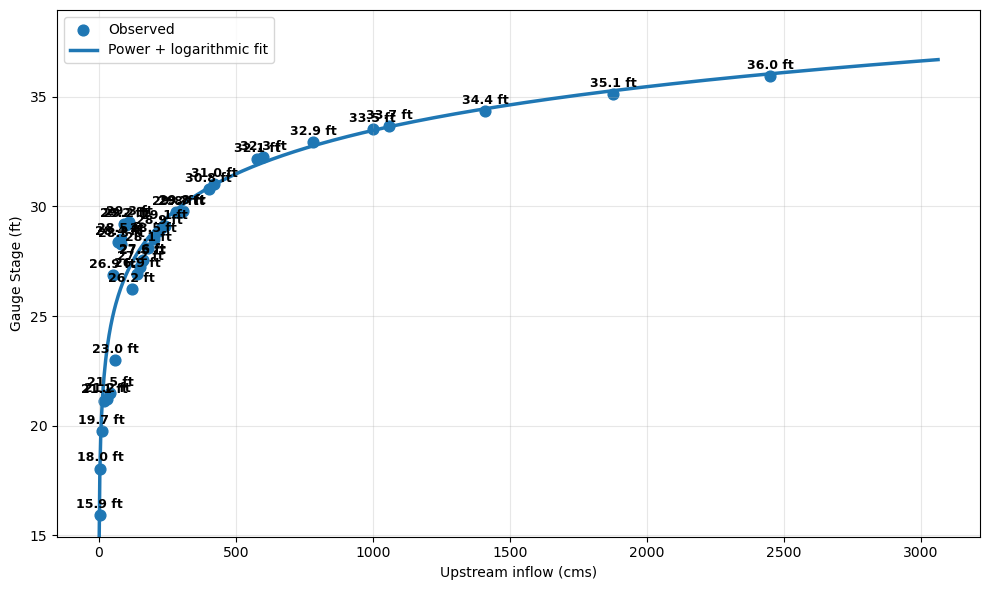

In [95]:
modeling_calibration_results["input_flows"] = get_input_flows_for_gauge_stages(
    modeling_results_directory = [calibration_one_results_dir, test_input_flow_results_dir] ,
    requested_WSE =  modeling_calibration_results["expected_WSE_m"],
    Guage_Datum_Offset= Gauge_Datum_offset,
    plot=True,
)

In [24]:
def get_input_flows_for_gauge_stages(
    modeling_results_directory,
    requested_WSE,
    Guage_Datum_Offset,
    plot=True,
    manually_exclude_outliers=False,
):

    # -----------------------------------------
    # ALLOW ONE DIRECTORY OR MULTIPLE DIRECTORIES
    # -----------------------------------------

    if not isinstance(
        modeling_results_directory,
        (list, tuple),
    ):
        modeling_results_directory = [
            modeling_results_directory
        ]


    # -----------------------------------------
    # COMBINE OWS FILES FROM ALL DIRECTORIES
    # -----------------------------------------

    ows_file_paths = {}

    for results_directory in modeling_results_directory:

        directory_files = gppf.get_flow_file_dict(
            results_directory,
            ".ows",
        )

        ows_file_paths.update(
            directory_files
        )


    # -----------------------------------------
    # READ OWS FILES
    # -----------------------------------------

    ows_file_read = {}

    for flow_cms, filepath in ows_file_paths.items():

        ows = gppf.read_GSSHA_ows(
            filepath.parent,
            filepath.name,
        )

        ows_file_read[flow_cms] = ows


    peak_wse = {}

    for flow_cms, df in ows_file_read.items():

        peak_wse[flow_cms] = (
            df["WSE_m"]
            .tail(120)
            .mean()
        )


    # -----------------------------------------
    # CURVE FUNCTION
    # -----------------------------------------

    def power_log_fit(
        q,
        a,
        b,
        c,
    ):

        q = np.asarray(
            q,
            dtype=float,
        )

        return (
            a * q**b
            + c * np.log1p(q)
        )


    # -----------------------------------------
    # CONVERT DICTIONARY TO ARRAYS
    # -----------------------------------------

    inflow = np.array(
        sorted(peak_wse.keys()),
        dtype=float,
    )

    wse = np.array(
        [peak_wse[q] for q in inflow],
        dtype=float,
    )


    # -----------------------------------------
    # FIRST FIT - ALL POINTS
    # -----------------------------------------

    params, covariance = curve_fit(
        power_log_fit,
        inflow,
        wse,
        p0=(2.0, 0.5, 0.2),
        bounds=(
            [0.0, 0.01, 0.0],
            [np.inf, 0.99, np.inf],
        ),
        maxfev=50000,
    )

    a, b, c = params


    # -----------------------------------------
    # CONVERT WSE TO GAUGE STAGE IN FEET
    # -----------------------------------------

    wse_ft = (
        wse / 0.3048
        + Guage_Datum_Offset
    )


    # -----------------------------------------
    # FIRST PLOT - ALL POINTS
    # -----------------------------------------

    if plot:

        q_plot = np.linspace(
            0,
            inflow.max() * 1.25,
            1000,
        )

        fitted_wse_ft = (
            power_log_fit(
                q_plot,
                a,
                b,
                c,
            )
            / 0.3048
            + Guage_Datum_Offset
        )

        fig, ax = plt.subplots(
            figsize=(10, 6)
        )

        ax.scatter(
            inflow,
            wse_ft,
            s=60,
            label="Observed",
        )

        for x, y in zip(
            inflow,
            wse_ft,
        ):

            ax.annotate(
                f"{y:.1f} ft",
                (x, y),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="black",
            )

        ax.plot(
            q_plot,
            fitted_wse_ft,
            linewidth=2.5,
            label="Power + logarithmic fit",
        )

        ax.set_xlabel(
            "Upstream inflow (cms)"
        )

        ax.set_ylabel(
            "Gauge Stage (ft)"
        )

        ax.set_ylim(
            wse_ft.min() - 1,
            wse_ft.max() + 3,
        )

        ax.grid(
            alpha=0.3
        )

        ax.legend()

        plt.tight_layout()
        plt.show()


    # -----------------------------------------
    # MANUAL OUTLIER EXCLUSION
    # -----------------------------------------

    keep_mask = np.ones(
        len(inflow),
        dtype=bool,
    )


    if manually_exclude_outliers:

        print(
            "\nAvailable gauge readings:"
        )

        for i, stage in enumerate(
            wse_ft
        ):

            print(
                f"{i}: "
                f"{stage:.1f} ft   "
                f"(inflow = {inflow[i]:.1f} cms)"
            )


        exclude_input = input(
            "\nEnter gauge readings to exclude "
            "separated by commas "
            "(example: 28.9, 29.3), "
            "or press Enter to keep all: "
        )


        if exclude_input.strip():

            exclude_stages = [
                float(x.strip())
                for x in exclude_input.split(",")
            ]


            for stage in exclude_stages:

                keep_mask &= ~np.isclose(
                    wse_ft,
                    stage,
                    atol=0.05,
                )


    # -----------------------------------------
    # DATA USED FOR FINAL FIT
    # -----------------------------------------

    inflow_fit = inflow[
        keep_mask
    ]

    wse_fit = wse[
        keep_mask
    ]


    # -----------------------------------------
    # FINAL FIT
    # -----------------------------------------

    params, covariance = curve_fit(
        power_log_fit,
        inflow_fit,
        wse_fit,
        p0=(2.0, 0.5, 0.2),
        bounds=(
            [0.0, 0.01, 0.0],
            [np.inf, 0.99, np.inf],
        ),
        maxfev=50000,
    )

    a, b, c = params


    # -----------------------------------------
    # FINAL FIT PREDICTIONS
    # -----------------------------------------

    wse_predicted = power_log_fit(
        inflow_fit,
        a,
        b,
        c,
    )


    # -----------------------------------------
    # STATISTICS
    # -----------------------------------------

    residuals = (
        wse_fit
        - wse_predicted
    )

    ss_res = np.sum(
        residuals**2
    )

    ss_tot = np.sum(
        (
            wse_fit
            - wse_fit.mean()
        )**2
    )

    r_squared = (
        1
        - ss_res / ss_tot
    )

    rmse = np.sqrt(
        np.mean(
            residuals**2
        )
    )


    print(
        f"\nR² = {r_squared:.6f}"
    )

    print(
        f"RMSE = {rmse:.6f}"
    )


    # -----------------------------------------
    # SECOND PLOT - AFTER EXCLUSIONS
    # -----------------------------------------

    if (
        plot
        and manually_exclude_outliers
    ):

        q_plot = np.linspace(
            0,
            inflow.max() * 1.25,
            1000,
        )

        fitted_wse_ft = (
            power_log_fit(
                q_plot,
                a,
                b,
                c,
            )
            / 0.3048
            + Guage_Datum_Offset
        )

        fig, ax = plt.subplots(
            figsize=(10, 6)
        )

        # Included points
        ax.scatter(
            inflow[keep_mask],
            wse_ft[keep_mask],
            s=60,
            label="Included",
        )

        # Excluded points
        if np.any(
            ~keep_mask
        ):

            ax.scatter(
                inflow[~keep_mask],
                wse_ft[~keep_mask],
                s=60,
                marker="x",
                label="Excluded",
            )

        # Label every point
        for x, y in zip(
            inflow,
            wse_ft,
        ):

            ax.annotate(
                f"{y:.1f} ft",
                (x, y),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="black",
            )

        ax.plot(
            q_plot,
            fitted_wse_ft,
            linewidth=2.5,
            label="Final fit",
        )

        ax.set_xlabel(
            "Upstream inflow (cms)"
        )

        ax.set_ylabel(
            "Gauge Stage (ft)"
        )

        ax.set_ylim(
            wse_ft.min() - 1,
            wse_ft.max() + 3,
        )

        ax.grid(
            alpha=0.3
        )

        ax.legend()

        plt.tight_layout()
        plt.show()


    # -----------------------------------------
    # INVERT FINAL CURVE
    # -----------------------------------------

    def invert_power_log_safe(
        target_wse,
        a,
        b,
        c,
        q_min=0.0,
        q_max=100000.0,
    ):

        def equation(q):

            return (
                a * q**b
                + c * np.log1p(q)
                - target_wse
            )


        if equation(q_min) > 0:

            return q_min


        while equation(q_max) < 0:

            q_max *= 2

            if q_max > 1e9:

                raise ValueError(
                    f"Could not bracket a solution "
                    f"for WSE={target_wse}"
                )


        return brentq(
            equation,
            q_min,
            q_max,
        )


    result = [

        invert_power_log_safe(
            target_wse,
            a,
            b,
            c,
        )

        for target_wse in requested_WSE
    ]


    return result

In [ ]:
%matplotlib notebook
modeling_calibration_results["input_flows"] = get_input_flows_for_gauge_stages(
    modeling_results_directory=[calibration_one_results_dir, test_input_flow_results_dir] ,
    requested_WSE=modeling_calibration_results["expected_WSE_m"],
    Guage_Datum_Offset=Gauge_Datum_offset,
    plot=True,
    manually_exclude_outliers=True,
)

%matplotlib inline

<IPython.core.display.Javascript object>


Available gauge readings:
0: 15.9 ft   (inflow = 2.0 cms)
1: 18.0 ft   (inflow = 5.0 cms)
2: 19.7 ft   (inflow = 10.0 cms)
3: 21.1 ft   (inflow = 20.0 cms)
4: 21.2 ft   (inflow = 30.0 cms)
5: 21.5 ft   (inflow = 40.0 cms)
6: 26.9 ft   (inflow = 50.0 cms)
7: 23.0 ft   (inflow = 60.0 cms)
8: 28.4 ft   (inflow = 70.0 cms)
9: 28.5 ft   (inflow = 79.0 cms)
10: 28.3 ft   (inflow = 80.0 cms)
11: 29.2 ft   (inflow = 90.0 cms)
12: 29.2 ft   (inflow = 100.0 cms)
13: 29.3 ft   (inflow = 111.0 cms)
14: 26.2 ft   (inflow = 120.0 cms)
15: 26.9 ft   (inflow = 140.0 cms)
16: 27.2 ft   (inflow = 150.0 cms)
17: 27.5 ft   (inflow = 157.0 cms)
18: 27.6 ft   (inflow = 160.0 cms)
19: 28.1 ft   (inflow = 180.0 cms)
20: 28.5 ft   (inflow = 200.0 cms)
21: 28.9 ft   (inflow = 219.0 cms)
22: 29.1 ft   (inflow = 240.0 cms)
23: 29.8 ft   (inflow = 280.0 cms)
24: 29.7 ft   (inflow = 300.0 cms)
25: 29.8 ft   (inflow = 306.0 cms)
26: 30.8 ft   (inflow = 400.0 cms)
27: 31.0 ft   (inflow = 420.0 cms)
28: 32.1 ft   (in

In [107]:
%matplotlib --list

Available matplotlib backends: ['agg', 'auto', 'gtk', 'gtk3', 'gtk4', 'inline', 'ipympl', 'nbagg', 'notebook', 'osx', 'pdf', 'ps', 'qt', 'qt4', 'qt5', 'qt6', 'svg', 'tk', 'webagg', 'widget', 'wx']


In [89]:
def get_input_flows_for_gauge_stages(
    modeling_results_directory,
    requested_WSE,
    Guage_Datum_Offset,
    plot=True,
    manually_exclude_outliers=False,
    b_increment=0.05,
    b_steps=3,
):

    # -----------------------------------------
    # READ MODEL GAUGE OUTPUT
    # -----------------------------------------

    ows_file_paths = gppf.get_flow_file_dict(
        modeling_results_directory,
        ".ows"
    )

    ows_file_read = {}

    for flow_cms, filepath in ows_file_paths.items():

        ows = gppf.read_GSSHA_ows(
            filepath.parent,
            filepath.name,
        )

        ows_file_read[flow_cms] = ows


    peak_wse = {}

    for flow_cms, df in ows_file_read.items():

        peak_wse[flow_cms] = (
            df["WSE_m"]
            .tail(120)
            .mean()
        )


    # -----------------------------------------
    # POWER + LOG FUNCTION
    # -----------------------------------------

    def power_log_fit(
        q,
        a,
        b,
        c,
    ):

        q = np.asarray(
            q,
            dtype=float,
        )

        return (
            a * q**b
            + c * np.log1p(q)
        )


    # -----------------------------------------
    # DATA ARRAYS
    # -----------------------------------------

    inflow = np.array(
        sorted(peak_wse.keys()),
        dtype=float,
    )

    wse = np.array(
        [peak_wse[q] for q in inflow],
        dtype=float,
    )


    wse_ft = (
        wse / 0.3048
        + Guage_Datum_Offset
    )


    # -----------------------------------------
    # FIRST FIT - ALL POINTS
    # -----------------------------------------

    params, covariance = curve_fit(
        power_log_fit,
        inflow,
        wse,
        p0=(2.0, 0.5, 0.2),
        bounds=(
            [0.0, 0.01, 0.0],
            [np.inf, 0.99, np.inf],
        ),
        maxfev=50000,
    )

    a, b, c = params


    # -----------------------------------------
    # FIRST PLOT - ALL POINTS
    # -----------------------------------------

    if plot:

        q_plot = np.linspace(
            0,
            inflow.max() * 1.25,
            1000,
        )

        fitted_wse_ft = (
            power_log_fit(
                q_plot,
                a,
                b,
                c,
            )
            / 0.3048
            + Guage_Datum_Offset
        )

        plt.figure(
            figsize=(10, 6)
        )

        plt.scatter(
            inflow,
            wse_ft,
            s=60,
            label="Observed",
        )


        for x, y in zip(
            inflow,
            wse_ft,
        ):

            plt.annotate(
                f"{y:.1f} ft",
                (x, y),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="black",
            )


        plt.plot(
            q_plot,
            fitted_wse_ft,
            linewidth=2.5,
            label=(
                f"Power + logarithmic fit "
                f"(b = {b:.4f})"
            ),
        )

        plt.xlabel(
            "Upstream inflow (cms)"
        )

        plt.ylabel(
            "Gauge Stage (ft)"
        )

        plt.ylim(
            wse_ft.min() - 1,
            wse_ft.max() + 3,
        )

        plt.grid(
            alpha=0.3
        )

        plt.legend()

        plt.tight_layout()

        plt.show()


    # -----------------------------------------
    # MANUAL OUTLIER EXCLUSION
    # -----------------------------------------

    keep_mask = np.ones(
        len(inflow),
        dtype=bool,
    )


    if manually_exclude_outliers:

        print(
            "\nAvailable gauge readings:"
        )


        for i, stage in enumerate(
            wse_ft
        ):

            print(
                f"{i}: "
                f"{stage:.1f} ft   "
                f"(inflow = {inflow[i]:.1f} cms)"
            )


        exclude_input = input(
            "\nEnter gauge readings to exclude "
            "separated by commas "
            "(example: 28.9, 29.3), "
            "or press Enter to keep all: "
        )


        if exclude_input.strip():

            exclude_stages = [
                float(x.strip())
                for x
                in exclude_input.split(",")
            ]


            for stage in exclude_stages:

                keep_mask &= ~np.isclose(
                    wse_ft,
                    stage,
                    atol=0.05,
                )


    # -----------------------------------------
    # FINAL FIT DATA
    # -----------------------------------------

    inflow_fit = inflow[
        keep_mask
    ]

    wse_fit = wse[
        keep_mask
    ]


    # -----------------------------------------
    # FINAL AUTOMATIC CURVE FIT
    # -----------------------------------------

    params, covariance = curve_fit(
        power_log_fit,
        inflow_fit,
        wse_fit,
        p0=(2.0, 0.5, 0.2),
        bounds=(
            [0.0, 0.01, 0.0],
            [np.inf, 0.99, np.inf],
        ),
        maxfev=50000,
    )

    a, b, c = params

    curve_fit_b = b


    # -----------------------------------------
    # FINAL FIT STATISTICS
    # -----------------------------------------

    wse_predicted = power_log_fit(
        inflow_fit,
        a,
        b,
        c,
    )


    residuals = (
        wse_fit
        - wse_predicted
    )


    ss_res = np.sum(
        residuals**2
    )


    ss_tot = np.sum(
        (
            wse_fit
            - wse_fit.mean()
        )**2
    )


    r_squared = (
        1
        - ss_res / ss_tot
    )


    rmse = np.sqrt(
        np.mean(
            residuals**2
        )
    )


    print(
        f"\nFinal curve-fit b = "
        f"{curve_fit_b:.6f}"
    )

    print(
        f"b increment = "
        f"{b_increment:.6f}"
    )

    print(
        f"R² = "
        f"{r_squared:.6f}"
    )

    print(
        f"RMSE = "
        f"{rmse:.6f}"
    )


    # -----------------------------------------
    # SECOND PLOT - FINAL AUTOMATIC FIT
    # -----------------------------------------

    if (
        plot
        and manually_exclude_outliers
    ):

        q_plot = np.linspace(
            0,
            inflow.max() * 1.25,
            1000,
        )


        fitted_wse_ft = (
            power_log_fit(
                q_plot,
                a,
                b,
                c,
            )
            / 0.3048
            + Guage_Datum_Offset
        )


        plt.figure(
            figsize=(10, 6)
        )


        plt.scatter(
            inflow[keep_mask],
            wse_ft[keep_mask],
            s=60,
            label="Included",
        )


        if np.any(
            ~keep_mask
        ):

            plt.scatter(
                inflow[~keep_mask],
                wse_ft[~keep_mask],
                s=60,
                marker="x",
                label="Excluded",
            )


        for x, y in zip(
            inflow,
            wse_ft,
        ):

            plt.annotate(
                f"{y:.1f} ft",
                (x, y),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="black",
            )


        plt.plot(
            q_plot,
            fitted_wse_ft,
            linewidth=2.5,
            label=(
                f"Final fit "
                f"(b = {curve_fit_b:.4f})"
            ),
        )


        plt.xlabel(
            "Upstream inflow (cms)"
        )

        plt.ylabel(
            "Gauge Stage (ft)"
        )


        plt.ylim(
            wse_ft.min() - 1,
            wse_ft.max() + 3,
        )


        plt.grid(
            alpha=0.3
        )


        plt.legend()

        plt.tight_layout()

        plt.show()


    # -----------------------------------------
    # TEST B VALUES ABOVE AND BELOW CURVE FIT
    # -----------------------------------------

    b_values = [
        curve_fit_b
        + i * b_increment

        for i in range(
            -b_steps,
            b_steps + 1,
        )
    ]


    # Keep b inside original allowed range
    b_values = [
        b_test

        for b_test
        in b_values

        if (
            b_test >= 0.01
            and b_test <= 0.99
        )
    ]


    def power_log_fit_fixed_b(
        q,
        a_fixed,
        c_fixed,
        b_fixed,
    ):

        q = np.asarray(
            q,
            dtype=float,
        )

        return (
            a_fixed * q**b_fixed
            + c_fixed * np.log1p(q)
        )


    b_test_results = {}


    for b_test in b_values:


        def fixed_b_function(
            q,
            a_test,
            c_test,
        ):

            return power_log_fit_fixed_b(
                q,
                a_test,
                c_test,
                b_test,
            )


        params_test, covariance_test = curve_fit(
            fixed_b_function,
            inflow_fit,
            wse_fit,
            p0=(
                a,
                c,
            ),
            bounds=(
                [0.0, 0.0],
                [np.inf, np.inf],
            ),
            maxfev=50000,
        )


        a_test, c_test = (
            params_test
        )


        predicted_test = (
            fixed_b_function(
                inflow_fit,
                a_test,
                c_test,
            )
        )


        residuals_test = (
            wse_fit
            - predicted_test
        )


        rmse_test = np.sqrt(
            np.mean(
                residuals_test**2
            )
        )


        ss_res_test = np.sum(
            residuals_test**2
        )


        r2_test = (
            1
            - ss_res_test / ss_tot
        )


        b_test_results[
            b_test
        ] = {
            "a": a_test,
            "c": c_test,
            "rmse": rmse_test,
            "r2": r2_test,
        }


    # -----------------------------------------
    # PRINT B TEST RESULTS
    # -----------------------------------------

    print(
        "\nB-value sensitivity:"
    )


    for b_test, values in (
        b_test_results.items()
    ):

        difference = (
            b_test
            - curve_fit_b
        )


        print(
            f"b = {b_test:.6f} "
            f"({difference:+.6f})   "
            f"R² = {values['r2']:.6f}   "
            f"RMSE = {values['rmse']:.6f}"
        )


    # -----------------------------------------
    # B SENSITIVITY PLOT
    # -----------------------------------------

    if plot:

        q_plot = np.linspace(
            0,
            inflow.max() * 1.25,
            1000,
        )


        plt.figure(
            figsize=(12, 8)
        )


        # Included points
        plt.scatter(
            inflow[keep_mask],
            wse_ft[keep_mask],
            s=70,
            zorder=10,
            label="Included GSSHA points",
        )


        # Excluded points
        if np.any(
            ~keep_mask
        ):

            plt.scatter(
                inflow[~keep_mask],
                wse_ft[~keep_mask],
                s=70,
                marker="x",
                zorder=10,
                label="Excluded",
            )


        # Point labels
        for x, y in zip(
            inflow,
            wse_ft,
        ):

            plt.annotate(
                f"{y:.1f} ft",
                (x, y),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="black",
            )


        # Candidate b curves
        for b_test, values in (
            b_test_results.items()
        ):

            a_test = values[
                "a"
            ]

            c_test = values[
                "c"
            ]


            curve_ft = (
                power_log_fit_fixed_b(
                    q_plot,
                    a_test,
                    c_test,
                    b_test,
                )
                / 0.3048
                + Guage_Datum_Offset
            )


            difference = (
                b_test
                - curve_fit_b
            )


            if np.isclose(
                b_test,
                curve_fit_b,
            ):

                plt.plot(
                    q_plot,
                    curve_ft,
                    linewidth=4,
                    label=(
                        f"Curve fit "
                        f"b = {b_test:.4f}"
                    ),
                )

            else:

                plt.plot(
                    q_plot,
                    curve_ft,
                    linewidth=1.5,
                    alpha=0.75,
                    label=(
                        f"b = {b_test:.4f} "
                        f"({difference:+.4f})"
                    ),
                )


        plt.xlabel(
            "Upstream inflow (cms)"
        )

        plt.ylabel(
            "Gauge Stage (ft)"
        )


        plt.title(
            "Power-Curve Sensitivity to b\n"
            f"Curve-fit b = "
            f"{curve_fit_b:.4f}   |   "
            f"Increment = "
            f"{b_increment:.4f}"
        )


        plt.ylim(
            wse_ft.min() - 1,
            wse_ft.max() + 3,
        )


        plt.grid(
            alpha=0.3
        )


        plt.legend(
            fontsize=9,
        )


        plt.tight_layout()

        plt.show()


    # -----------------------------------------
    # INVERT FINAL AUTOMATIC FIT
    # -----------------------------------------

    def invert_power_log_safe(
        target_wse,
        a,
        b,
        c,
        q_min=0.0,
        q_max=100000.0,
    ):

        def equation(q):

            return (
                a * q**b
                + c * np.log1p(q)
                - target_wse
            )


        if equation(
            q_min
        ) > 0:

            return q_min


        while equation(
            q_max
        ) < 0:

            q_max *= 2


            if q_max > 1e9:

                raise ValueError(
                    f"Could not bracket a solution "
                    f"for WSE={target_wse}"
                )


        return brentq(
            equation,
            q_min,
            q_max,
        )


    result = [

        invert_power_log_safe(
            target_wse,
            a,
            b,
            c,
        )

        for target_wse
        in requested_WSE
    ]


    return result

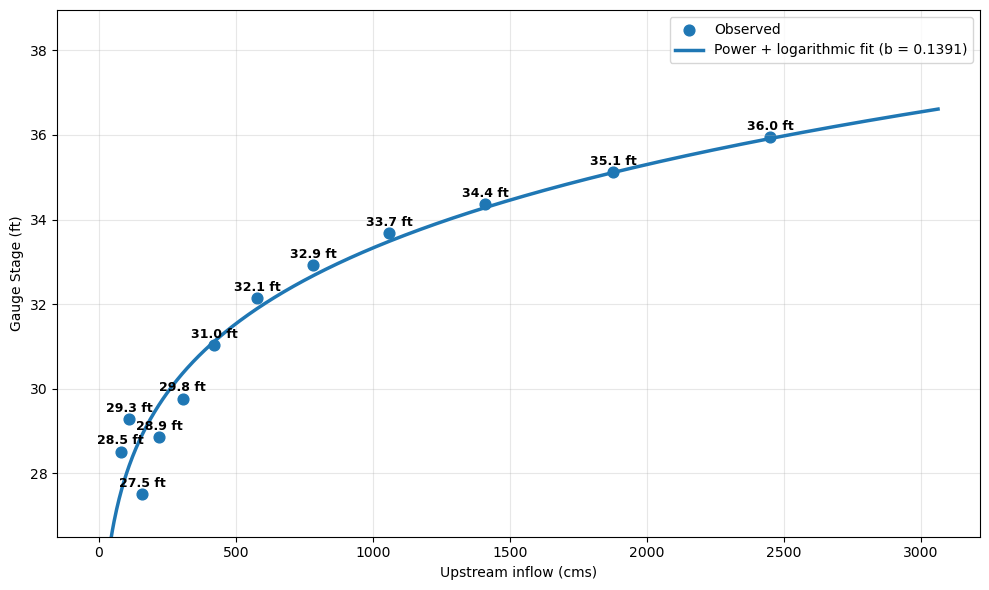


Available gauge readings:
0: 28.5 ft   (inflow = 79.0 cms)
1: 29.3 ft   (inflow = 111.0 cms)
2: 27.5 ft   (inflow = 157.0 cms)
3: 28.9 ft   (inflow = 219.0 cms)
4: 29.8 ft   (inflow = 306.0 cms)
5: 31.0 ft   (inflow = 420.0 cms)
6: 32.1 ft   (inflow = 578.0 cms)
7: 32.9 ft   (inflow = 783.0 cms)
8: 33.7 ft   (inflow = 1060.0 cms)
9: 34.4 ft   (inflow = 1411.0 cms)
10: 35.1 ft   (inflow = 1877.0 cms)
11: 36.0 ft   (inflow = 2451.0 cms)



Enter gauge readings to exclude separated by commas (example: 28.9, 29.3), or press Enter to keep all:  28.5, 29.3



Final curve-fit b = 0.313861
b increment = 0.050000
R² = 0.991493
RMSE = 0.074648


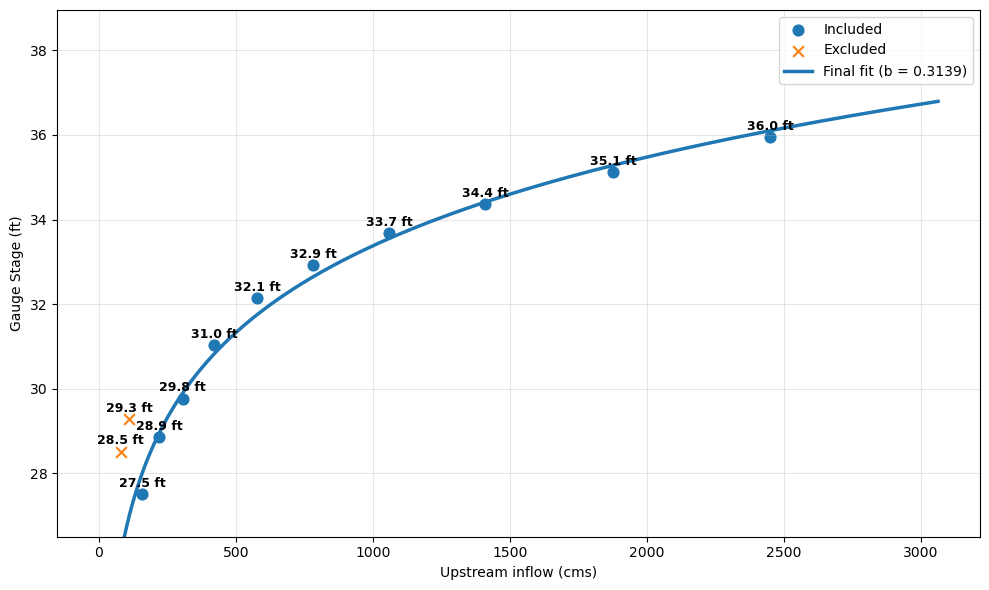


B-value sensitivity:
b = 0.163861 (-0.150000)   R² = 0.989483   RMSE = 0.082997
b = 0.213861 (-0.100000)   R² = 0.991071   RMSE = 0.076474
b = 0.263861 (-0.050000)   R² = 0.991433   RMSE = 0.074907
b = 0.313861 (+0.000000)   R² = 0.991493   RMSE = 0.074648
b = 0.363861 (+0.050000)   R² = 0.991462   RMSE = 0.074782
b = 0.413861 (+0.100000)   R² = 0.991396   RMSE = 0.075073
b = 0.463861 (+0.150000)   R² = 0.991313   RMSE = 0.075433


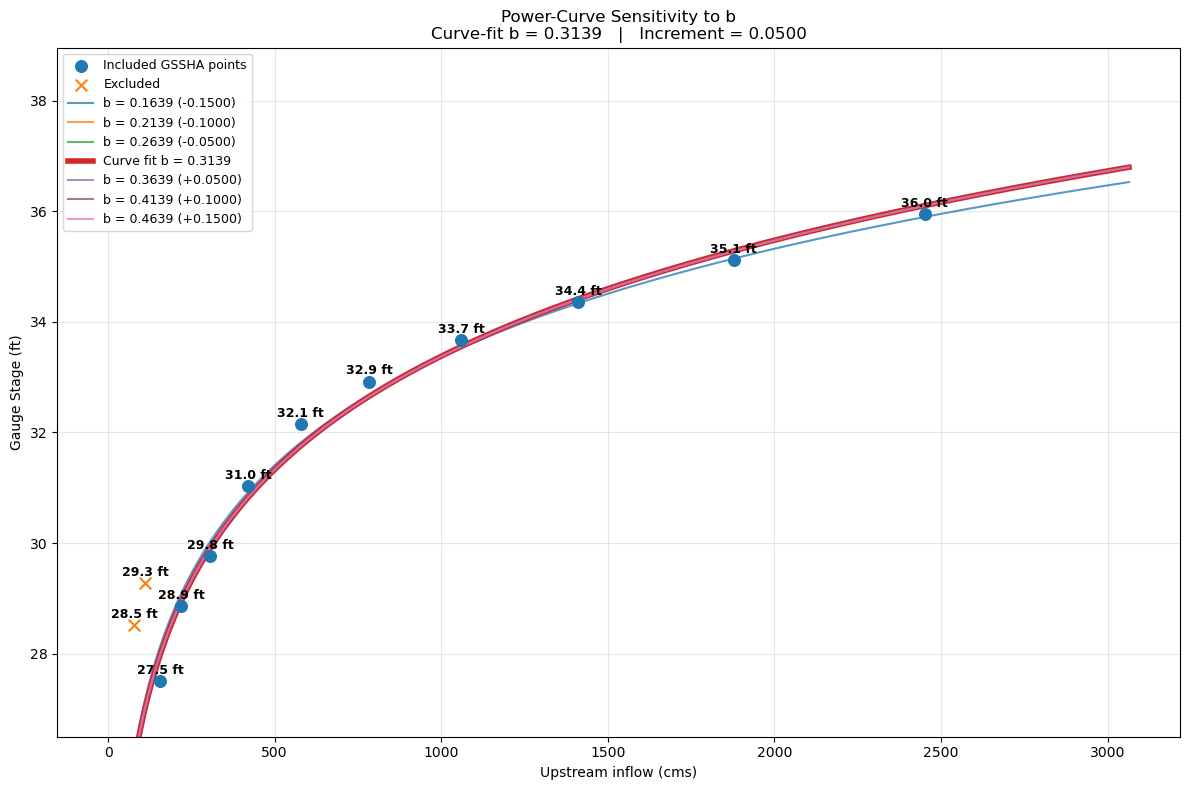

In [90]:
modeling_calibration_results["input_flows"] = get_input_flows_for_gauge_stages(
    modeling_results_directory=calibration_one_results_dir,
    requested_WSE=modeling_calibration_results["expected_WSE_m"],
    Guage_Datum_Offset=Gauge_Datum_offset,
    plot=True,
    manually_exclude_outliers=True,
    b_increment=0.05,
    b_steps=3,
)

In [87]:
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq

def get_input_flows_for_gauge_stages(
    modeling_results_directory,
    requested_WSE,
    Guage_Datum_Offset,
    plot=True,
    manually_exclude_outliers=False,
):

    # read model gauge output from GSSHA
    ows_file_paths = gppf.get_flow_file_dict(
        modeling_results_directory,
        ".ows"
    )

    ows_file_read = {}

    for flow_cms, filepath in ows_file_paths.items():

        ows = gppf.read_GSSHA_ows(
            filepath.parent,
            filepath.name,
        )

        ows_file_read[flow_cms] = ows


    peak_wse = {}

    for flow_cms, df in ows_file_read.items():

        peak_wse[flow_cms] = (
            df["WSE_m"]
            .tail(120)
            .mean()
        )


    # Convert dictionary to arrays
    inflow = np.array(
        sorted(peak_wse.keys()),
        dtype=float,
    )

    wse = np.array(
        [peak_wse[q] for q in inflow],
        dtype=float,
    )


    # Gauge stage in feet for plotting only
    wse_ft = (
        wse / 0.3048
        + Guage_Datum_Offset
    )


    # -----------------------------------------
    # FIRST PCHIP - ALL POINTS
    # -----------------------------------------

    pchip_all = PchipInterpolator(
        inflow,
        wse,
    )


    # -----------------------------------------
    # FIRST PLOT - ALL POINTS
    # -----------------------------------------

    if plot:

        q_plot = np.linspace(
            inflow.min(),
            inflow.max(),
            1000,
        )

        fitted_wse_ft = (
            pchip_all(q_plot)
            / 0.3048
            + Guage_Datum_Offset
        )

        plt.figure(
            figsize=(10, 6)
        )

        plt.scatter(
            inflow,
            wse_ft,
            s=60,
            label="Observed",
        )

        for x, y in zip(
            inflow,
            wse_ft,
        ):

            plt.annotate(
                f"{y:.1f} ft",
                (x, y),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="black",
            )

        plt.plot(
            q_plot,
            fitted_wse_ft,
            linewidth=2.5,
            label="PCHIP interpolation",
        )

        plt.xlabel(
            "Upstream inflow (cms)"
        )

        plt.ylabel(
            "Gauge Stage (ft)"
        )

        plt.ylim(
            wse_ft.min() - 1,
            wse_ft.max() + 3,
        )

        plt.grid(
            alpha=0.3
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


    # -----------------------------------------
    # MANUAL OUTLIER EXCLUSION
    # -----------------------------------------

    keep_mask = np.ones(
        len(inflow),
        dtype=bool,
    )


    if manually_exclude_outliers:

        print(
            "\nAvailable gauge readings:"
        )

        for i, stage in enumerate(wse_ft):

            print(
                f"{i}: "
                f"{stage:.1f} ft   "
                f"(inflow = {inflow[i]:.1f} cms)"
            )


        exclude_input = input(
            "\nEnter gauge readings to exclude "
            "separated by commas "
            "(example: 28.9, 29.3), "
            "or press Enter to keep all: "
        )


        if exclude_input.strip():

            exclude_stages = [
                float(x.strip())
                for x in exclude_input.split(",")
            ]


            for stage in exclude_stages:

                keep_mask &= ~np.isclose(
                    wse_ft,
                    stage,
                    atol=0.05,
                )


    # -----------------------------------------
    # DATA USED FOR FINAL PCHIP
    # -----------------------------------------

    inflow_fit = inflow[keep_mask]

    wse_fit = wse[keep_mask]


    if len(inflow_fit) < 2:

        raise ValueError(
            "At least two included points are required "
            "for PCHIP interpolation."
        )


    # -----------------------------------------
    # FINAL PCHIP
    # -----------------------------------------

    pchip_fit = PchipInterpolator(
        inflow_fit,
        wse_fit,
    )


    # Predictions exactly at included points
    wse_predicted = pchip_fit(
        inflow_fit
    )


    # -----------------------------------------
    # STATISTICS
    # -----------------------------------------

    residuals = (
        wse_fit
        - wse_predicted
    )

    ss_res = np.sum(
        residuals**2
    )

    ss_tot = np.sum(
        (
            wse_fit
            - wse_fit.mean()
        )**2
    )


    if ss_tot == 0:

        r_squared = np.nan

    else:

        r_squared = (
            1
            - ss_res / ss_tot
        )


    rmse = np.sqrt(
        np.mean(
            residuals**2
        )
    )


    print(
        f"\nR² = {r_squared:.6f}"
    )

    print(
        f"RMSE = {rmse:.6f}"
    )


    # -----------------------------------------
    # SECOND PLOT - AFTER EXCLUSIONS
    # -----------------------------------------

    if (
        plot
        and manually_exclude_outliers
    ):

        q_plot = np.linspace(
            inflow_fit.min(),
            inflow_fit.max(),
            1000,
        )


        fitted_wse_ft = (
            pchip_fit(q_plot)
            / 0.3048
            + Guage_Datum_Offset
        )


        plt.figure(
            figsize=(10, 6)
        )


        # Included points
        plt.scatter(
            inflow[keep_mask],
            wse_ft[keep_mask],
            s=60,
            label="Included",
        )


        # Excluded points
        if np.any(~keep_mask):

            plt.scatter(
                inflow[~keep_mask],
                wse_ft[~keep_mask],
                s=60,
                marker="x",
                label="Excluded",
            )


        # Label every point
        for x, y in zip(
            inflow,
            wse_ft,
        ):

            plt.annotate(
                f"{y:.1f} ft",
                (x, y),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="black",
            )


        plt.plot(
            q_plot,
            fitted_wse_ft,
            linewidth=2.5,
            label="PCHIP interpolation",
        )

        plt.xlabel(
            "Upstream inflow (cms)"
        )

        plt.ylabel(
            "Gauge Stage (ft)"
        )

        plt.ylim(
            wse_ft.min() - 1,
            wse_ft.max() + 3,
        )

        plt.grid(
            alpha=0.3
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


    # -----------------------------------------
    # INVERT PCHIP
    # -----------------------------------------

    def invert_pchip_safe(
        target_wse,
    ):

        def equation(q):

            return (
                pchip_fit(q)
                - target_wse
            )


        q_min = inflow_fit.min()
        q_max = inflow_fit.max()


        wse_min = pchip_fit(q_min)
        wse_max = pchip_fit(q_max)


        if target_wse < min(
            wse_min,
            wse_max,
        ):

            raise ValueError(
                f"Requested WSE {target_wse} is below "
                f"the PCHIP calibration range."
            )


        if target_wse > max(
            wse_min,
            wse_max,
        ):

            raise ValueError(
                f"Requested WSE {target_wse} is above "
                f"the PCHIP calibration range."
            )


        return brentq(
            equation,
            q_min,
            q_max,
        )


    result = [

        invert_pchip_safe(
            target_wse,
        )

        for target_wse
        in requested_WSE
    ]


    return result

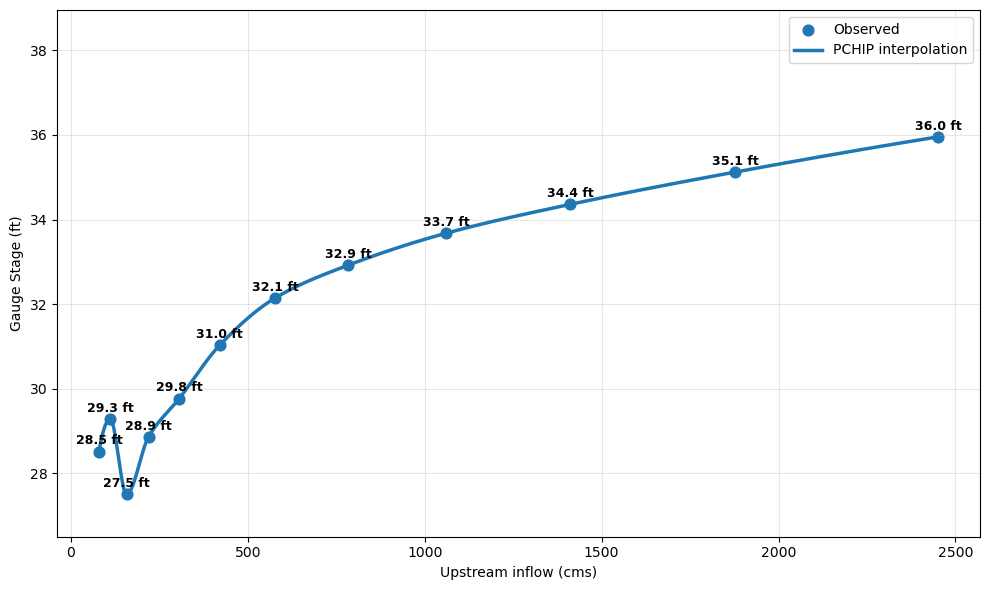


Available gauge readings:
0: 28.5 ft   (inflow = 79.0 cms)
1: 29.3 ft   (inflow = 111.0 cms)
2: 27.5 ft   (inflow = 157.0 cms)
3: 28.9 ft   (inflow = 219.0 cms)
4: 29.8 ft   (inflow = 306.0 cms)
5: 31.0 ft   (inflow = 420.0 cms)
6: 32.1 ft   (inflow = 578.0 cms)
7: 32.9 ft   (inflow = 783.0 cms)
8: 33.7 ft   (inflow = 1060.0 cms)
9: 34.4 ft   (inflow = 1411.0 cms)
10: 35.1 ft   (inflow = 1877.0 cms)
11: 36.0 ft   (inflow = 2451.0 cms)



Enter gauge readings to exclude separated by commas (example: 28.9, 29.3), or press Enter to keep all:  



R² = 1.000000
RMSE = 0.000000


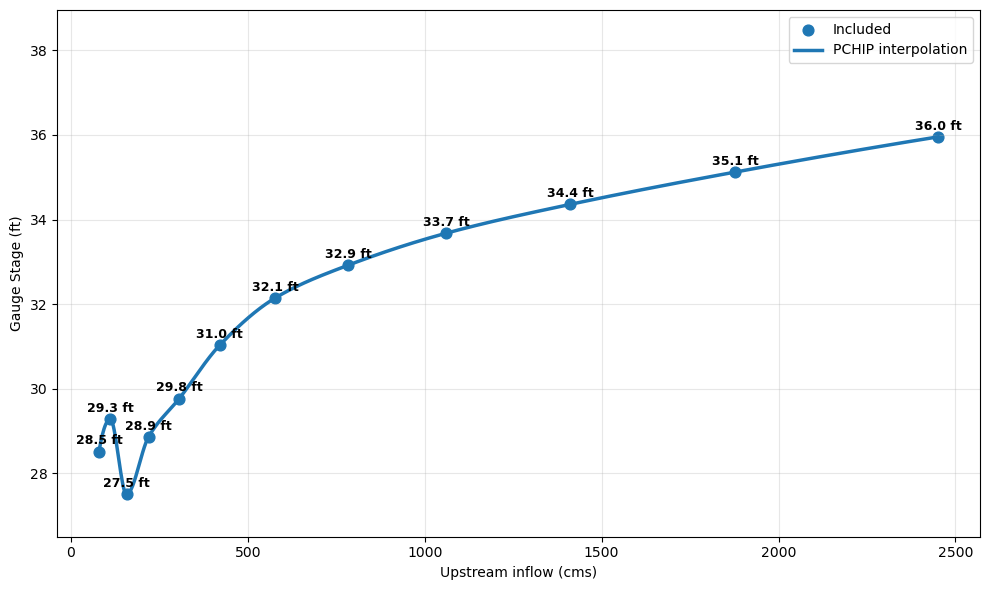

ValueError: Requested WSE 3.71 is below the PCHIP calibration range.

In [88]:
modeling_calibration_results["input_flows"] = get_input_flows_for_gauge_stages(
    modeling_results_directory=calibration_one_results_dir,
    requested_WSE=modeling_calibration_results["expected_WSE_m"],
    Guage_Datum_Offset=Gauge_Datum_offset,
    plot=True,
    manually_exclude_outliers=True,
)

MODEL TIMESTEP CONVERGENCE (YOU CHANGE PARAMETERS BASED ON GRAPH)

In [ ]:
# gppf.view_timestep_convergence(model_results_directory = calibration_one_results_dir, area_change_threshold = 1000, number_timesteps_below_threshold = 6)

In [ ]:
# medium_flow_threshold = 400
# high_flow_threshold = 1000

# low_flow_timing = 1000
# medium_flow_timing = 420
# high_flow_timing = 330


# modeling_calibration_results["convergence_time"] = gppf.predict_timestep_convergence(
#     modeling_calibration_results["input_flows"],
#     medium_flow_threshold,
#     high_flow_threshold,
#     low_flow_timing,
#     medium_flow_timing,
#     high_flow_timing,
# )

# 3.1 Run model until it reaches the gauge's 100 year streamflow threshold

Use USGS Stats to find the streamflow amount (convert that to cms). IF USGS Stats doesn't have the value reported, you can try using PeakFQ from their website

In [ ]:
# one_hundred_year_threshold = _________ #must be in CMS : cfs * 0.028316846592

# final_stage_maps_results_dir = model_dir / ("FINAL_STAGE_MAPS_WITH_OFFSET_" + str(offset))
# final_stage_maps_results_dir.mkdir(parents=True, exist_ok=True)